In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, PowerTransformer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import shap

In [2]:
counties = pd.read_csv('counties_v1.csv')

counties.head()

organizational_columns = ['ID', 'Name']

outcome_variables = [
    'Population Change %',
    'Employment Change %',
    'Establishment Change %',
    'GDP Growth %'
]

feature_variables = [col for col in counties.columns if col not in outcome_variables + organizational_columns]

X = counties[feature_variables]
y = counties[outcome_variables]

# Detect all numeric features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify one-hot encoded features: binary 0/1 columns (exclude all-0 or all-1)
one_hot_features = [
    col for col in X
    if set(X[col].dropna().unique()) <= {0, 1} and X[col].nunique() > 1
]

# Final numeric features to scale (exclude one-hot)
scaled_numeric_features = [col for col in numeric_features if col not in one_hot_features]

# Check for mistakes
print("Scaled numeric features:", scaled_numeric_features)
print("One-hot encoded features:", one_hot_features)
print("Total features (check):", len(scaled_numeric_features) + len(one_hot_features))
print("Original X features:", len(X.columns))

Scaled numeric features: ["Percent w/ Bachelor's+", 'Unemployment', 'Annual Cost', 'Median Family Income', 'Average Temperature', 'Pct Wage Change', 'Average Annual Pay', 'Population']
One-hot encoded features: ['Region_Great_Lakes', 'Region_Midwest', 'Region_Mountains', 'Region_New_England', 'Region_Southeast', 'Region_Southwest', 'Region_West_Coast', 'State_AR', 'State_AZ', 'State_CA', 'State_CO', 'State_CO*', 'State_DE', 'State_FL', 'State_GA', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI', 'State_SC', 'State_SD', 'State_SD*', 'State_TN', 'State_TX', 'State_UT', 'State_VA', 'State_VA*', 'State_VT', 'State_WA', 'State_WI', 'State_WV', 'State_WY']
Total features (check): 64
Original X features: 64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled_num = X_scaler.fit_transform(X_train[scaled_numeric_features])
X_test_scaled_num = X_scaler.transform(X_test[scaled_numeric_features])

# Keep one-hot features unscaled
X_train_onehot = X_train[one_hot_features].reset_index(drop=True)
X_test_onehot = X_test[one_hot_features].reset_index(drop=True)

# Recombine
X_train_scaled = pd.DataFrame(X_train_scaled_num, columns=scaled_numeric_features).reset_index(drop=True)
X_test_scaled = pd.DataFrame(X_test_scaled_num, columns=scaled_numeric_features).reset_index(drop=True)

X_train_final = pd.concat([X_train_scaled, X_train_onehot], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_onehot], axis=1)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.fit_transform(y_test)

X_train_final.head()



,Percent w/ Bachelor's+,Unemployment,Annual Cost,Median Family Income,Average Temperature,Pct Wage Change,Average Annual Pay,Population,Region_Great_Lakes,Region_Midwest,...,State_TN,State_TX,State_UT,State_VA,State_VA*,State_VT,State_WA,State_WI,State_WV,State_WY
0,-0.415354,-1.164591,-0.644930,0.021337,-0.848138,-0.268048,0.040629,-0.324440,False,True,...,False,False,False,False,False,False,False,False,False,False
1,-0.435458,0.435641,-0.531292,-0.363304,1.394428,-0.005539,-0.264418,-0.328152,False,False,...,False,True,False,False,False,False,False,False,False,False
2,0.397531,0.688309,0.498618,-1.373769,-1.502220,0.240564,-1.158917,-0.340691,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-1.011179,-0.575032,0.119033,-0.441729,1.055707,-0.366489,-0.469957,-0.264423,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.258188,-0.743477,-0.118133,0.087540,0.495065,-0.005539,-0.241148,-0.166570,False,False,...,True,False,False,False,False,False,False,False,False,False


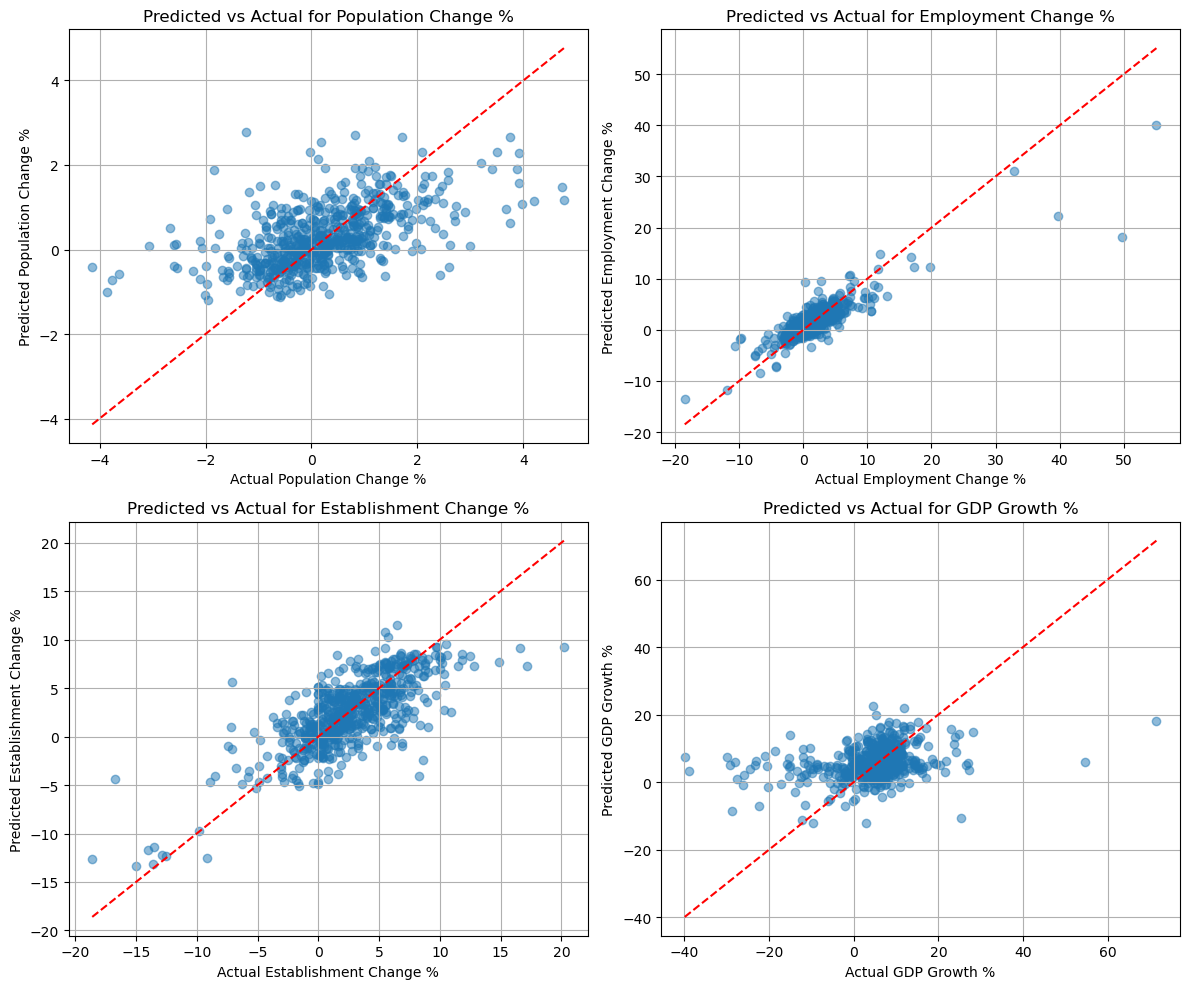

In [4]:
base_model = LinearRegression()
multioutput_model = MultiOutputRegressor(base_model)

multioutput_model.fit(X_train_final, y_train)

y_pred = multioutput_model.predict(X_test_final)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid
axes = axes.flatten()  # Flatten to iterate easily

for i, outcome in enumerate(outcome_variables):
    ax = axes[i]
    ax.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.5)
    ax.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 
            [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 
            'r--')
    ax.set_xlabel('Actual ' + outcome)
    ax.set_ylabel('Predicted ' + outcome)
    ax.set_title('Predicted vs Actual for ' + outcome)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [5]:
results = []

for i, outcome in enumerate(outcome_variables):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    rmse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i], squared=False)
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    
    results.append({
        'Outcome Variable': outcome,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_lr_df = pd.DataFrame(results)

results_lr_df.head()

,Outcome Variable,R² Score,RMSE,MAE
0,Population Change %,0.282164,0.996744,0.723448
1,Employment Change %,0.738500,2.457727,1.451059
2,Establishment Change %,0.548143,2.868853,2.137042
3,GDP Growth %,0.040408,8.848540,5.667106


In [6]:
# Store models and results
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),  # Lasso needs smaller alpha to avoid zeroing out everything
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

results = {}

# Fit and evaluate each model
for name, model in models.items():
    print(f"\n{name} Regression:")
    mo_model = MultiOutputRegressor(model)
    mo_model.fit(X_train_final, y_train)
    y_pred = mo_model.predict(X_test_final)

    # R² scores per output
    r2_scores = [
        r2_score(y_test.iloc[:, i], y_pred[:, i])
        for i in range(y_test.shape[1])
    ]

    results[name] = r2_scores

    for i, outcome in enumerate(y_test.columns):
        print(f"  {outcome} R²: {r2_scores[i]:.3f}")

    # Optional: Coefficient sparsity check (Lasso only)
    if name == "Lasso":
        coefs = np.array([est.coef_ for est in mo_model.estimators_])
        num_zeros = (coefs == 0).sum(axis=1)
        print(f"  Avg # of zeroed-out coefficients per output: {np.mean(num_zeros):.1f}")



Ridge Regression:
  Population Change % R²: 0.285
  Employment Change % R²: 0.741
  Establishment Change % R²: 0.648
  GDP Growth % R²: 0.122

Lasso Regression:
  Population Change % R²: 0.063
  Employment Change % R²: 0.724
  Establishment Change % R²: 0.327
  GDP Growth % R²: 0.085
  Avg # of zeroed-out coefficients per output: 56.0

ElasticNet Regression:
  Population Change % R²: -0.006
  Employment Change % R²: 0.535
  Establishment Change % R²: 0.011
  GDP Growth % R²: 0.008


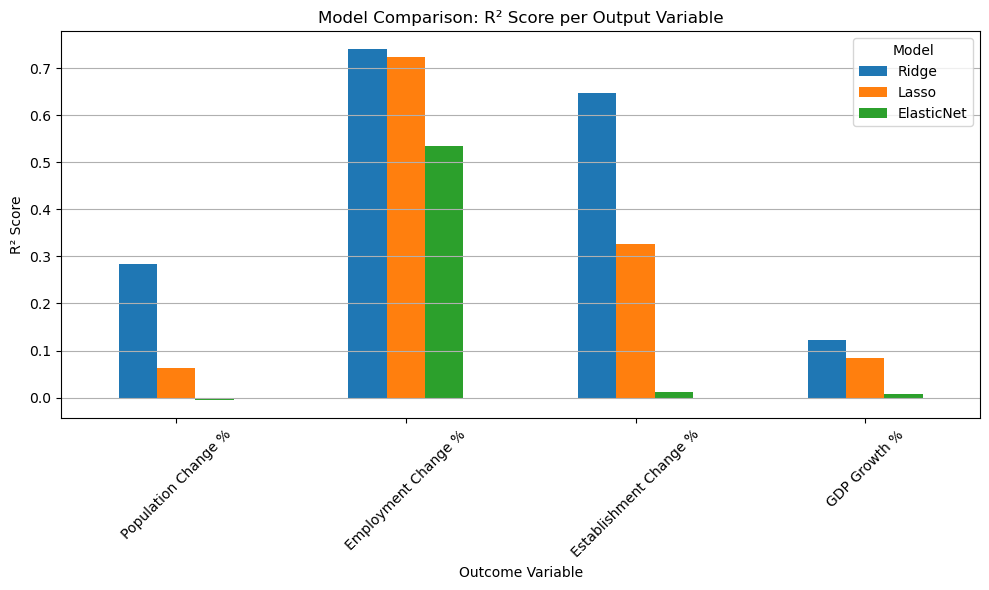

In [7]:
results_df = pd.DataFrame(results, index=y_test.columns)

# Plot
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Comparison: R² Score per Output Variable")
plt.ylabel("R² Score")
plt.xlabel("Outcome Variable")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

# Define a range of alpha values to test
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

# Set up the model
ridge_base = Ridge()
ridge_cv = MultiOutputRegressor(ridge_base)

# Wrap in GridSearch
param_grid = {'estimator__alpha': alpha_values}

grid_search = GridSearchCV(
    ridge_cv,
    param_grid,
    scoring='r2',
    cv=5,  # 5-fold cross-validation
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

print("Best alpha:", grid_search.best_params_['estimator__alpha'])
print("Best cross-validated R² score:", grid_search.best_score_)

Best alpha: 1.0
Best cross-validated R² score: 0.41168715096872777


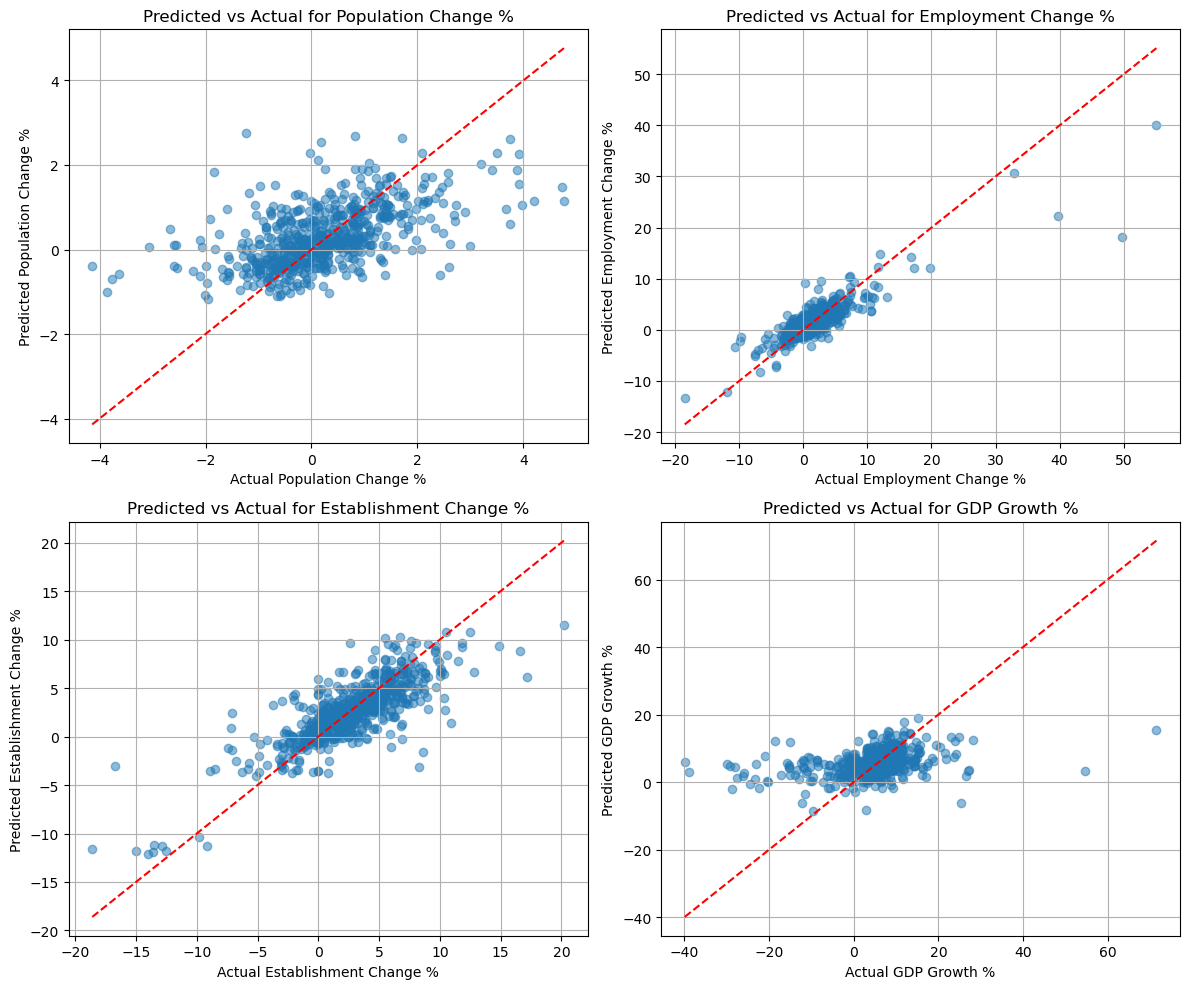

In [9]:
best_alpha = grid_search.best_params_['estimator__alpha']
final_ridge_model = MultiOutputRegressor(Ridge(alpha=best_alpha))
final_ridge_model.fit(X_train_final, y_train)

# Predict on test data
y_pred_ridge_final = final_ridge_model.predict(X_test_final)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid
axes = axes.flatten()  # Flatten to iterate easily

for i, outcome in enumerate(outcome_variables):
    ax = axes[i]
    ax.scatter(y_test.iloc[:, i], y_pred_ridge_final[:, i], alpha=0.5)
    ax.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 
            [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 
            'r--')
    ax.set_xlabel('Actual ' + outcome)
    ax.set_ylabel('Predicted ' + outcome)
    ax.set_title('Predicted vs Actual for ' + outcome)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [10]:
results_ridge = []

for i, outcome in enumerate(outcome_variables):
    r2 = r2_score(y_test.iloc[:, i], y_pred_ridge_final[:, i])
    rmse = mean_squared_error(y_test.iloc[:, i], y_pred_ridge_final[:, i], squared=False)
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_ridge_final[:, i])
    
    results_ridge.append({
        'Outcome Variable': outcome,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_ridge_df = pd.DataFrame(results_ridge)

results_ridge_df.head()

,Outcome Variable,R² Score,RMSE,MAE
0,Population Change %,0.284681,0.994995,0.721680
1,Employment Change %,0.740672,2.447498,1.439627
2,Establishment Change %,0.647896,2.532462,1.804356
3,GDP Growth %,0.122403,8.462056,5.075577


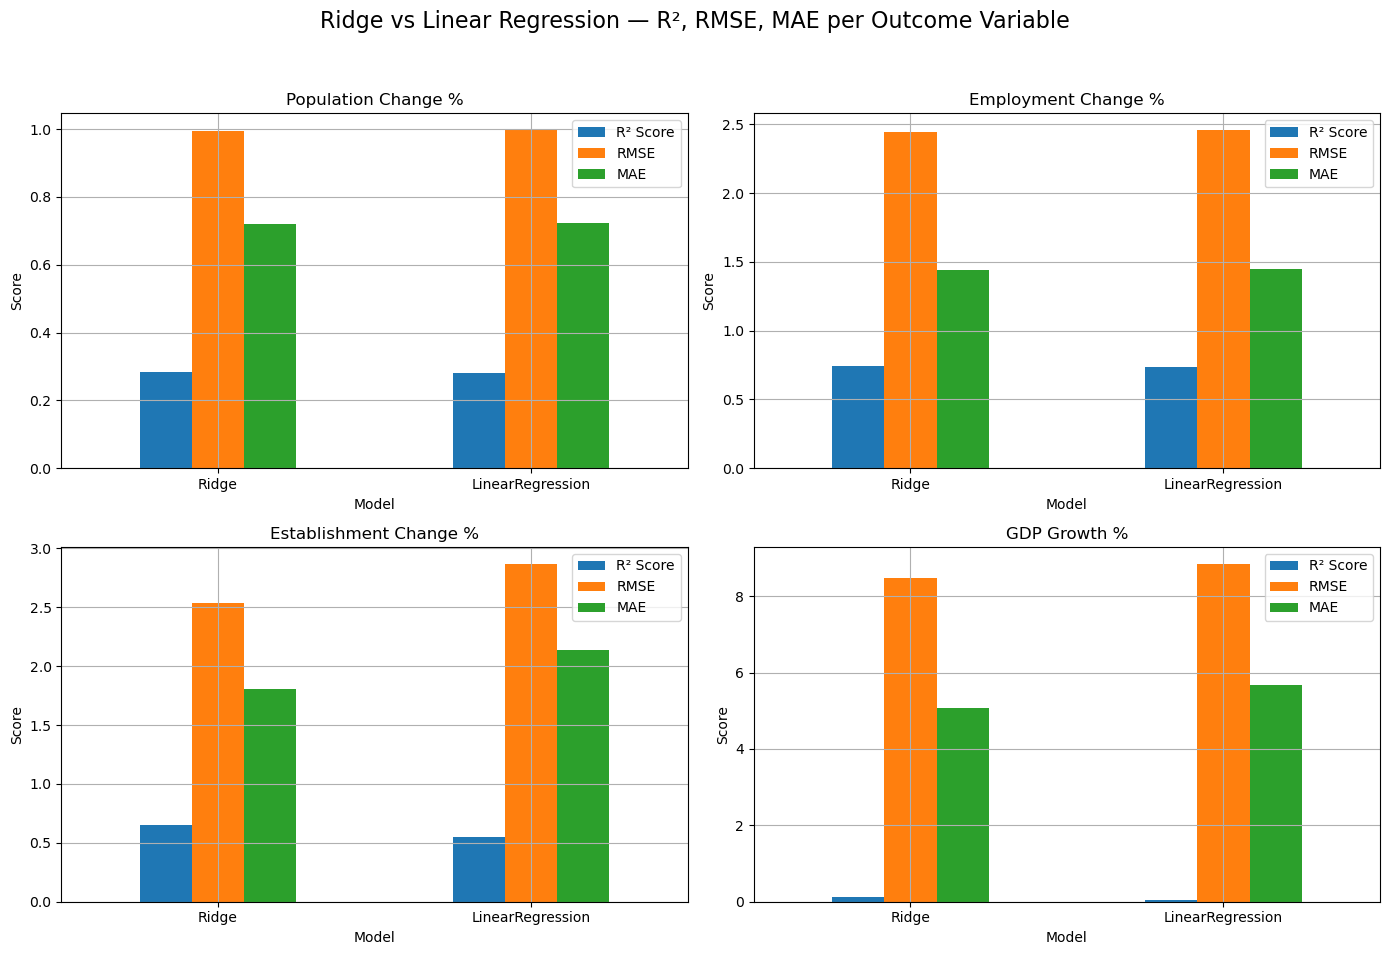

In [11]:
# Add model labels
results_ridge_df['Model'] = 'Ridge'
results_lr_df['Model'] = 'LinearRegression'

# Combine into one long DataFrame for seaborn-style plotting
combined_df = pd.concat([results_ridge_df, results_lr_df], ignore_index=True)

metrics = ['R² Score', 'RMSE', 'MAE']
outcomes = outcome_variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, outcome in enumerate(outcomes):
    subset = combined_df[combined_df['Outcome Variable'] == outcome]
    
    # Convert to plotting format
    metric_values = {
        metric: subset.set_index('Model')[metric] for metric in metrics
    }
    
    df_plot = pd.DataFrame(metric_values)

    # Plot
    df_plot.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"{outcome}")
    axes[i].set_ylabel("Score")
    axes[i].set_xticklabels(df_plot.index, rotation=0)
    axes[i].legend(loc='best')
    axes[i].grid(True)

plt.suptitle("Ridge vs Linear Regression — R², RMSE, MAE per Outcome Variable", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



The figure layout has changed to tight
The figure layout has changed to tight
The figure layout has changed to tight


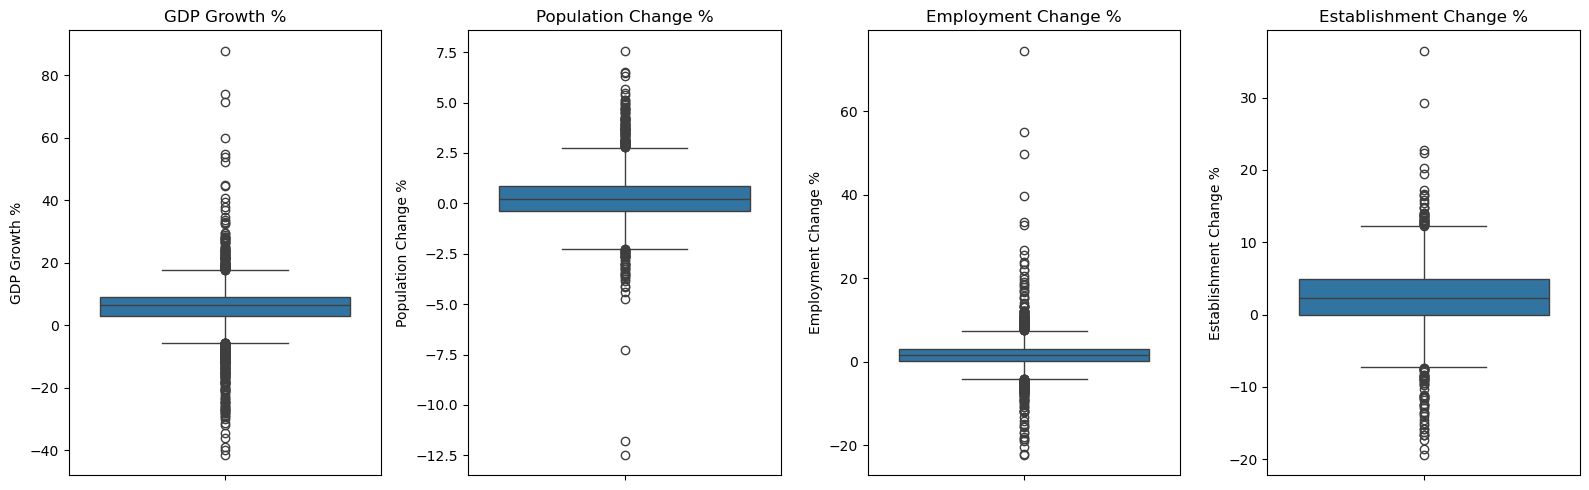

Population Change %       151
Employment Change %       223
Establishment Change %     97
GDP Growth %              316
Name: Outlier Count, dtype: int64
787


In [12]:
plt.figure(figsize=(16, 5))

# List of outcome variables
outcome_vars = ['GDP Growth %', 'Population Change %', 'Employment Change %', 'Establishment Change %']

# Plot each as a subplot (1 row, 4 columns)
for i, var in enumerate(outcome_vars):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(y=y[var])
    plt.title(var)
    plt.tight_layout()

plt.show()


def count_outliers_iqr(df, columns=None):
    if columns is None:
        columns = df.select_dtypes(include='number').columns  # default: all numeric columns

    outlier_counts = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = outliers.shape[0]

    return pd.Series(outlier_counts, name='Outlier Count')

# Example usage
outlier_summary = count_outliers_iqr(counties[['Population Change %', 'Employment Change %', 'Establishment Change %', 'GDP Growth %']])
print(outlier_summary)
print(outlier_summary.sum())


In [13]:
print(y_test.describe())
print(results_ridge_df.head())

       Population Change %  Employment Change %  Establishment Change %  \
count           609.000000           609.000000              609.000000   
mean              0.228355             1.914450                2.583580   
std               1.177411             4.810107                4.271343   
min              -4.139610           -18.500000              -18.600000   
25%              -0.497660             0.200000                0.300000   
50%               0.150330             1.500000                2.500000   
75%               0.860262             3.000000                5.300000   
max               4.765573            55.100000               20.200000   

       GDP Growth %  
count    609.000000  
mean       4.811561  
std        9.040349  
min      -39.936956  
25%        2.874117  
50%        6.114165  
75%        8.625255  
max       71.524482  
         Outcome Variable  R² Score      RMSE       MAE  Model
0     Population Change %  0.284681  0.994995  0.721680  Ridge


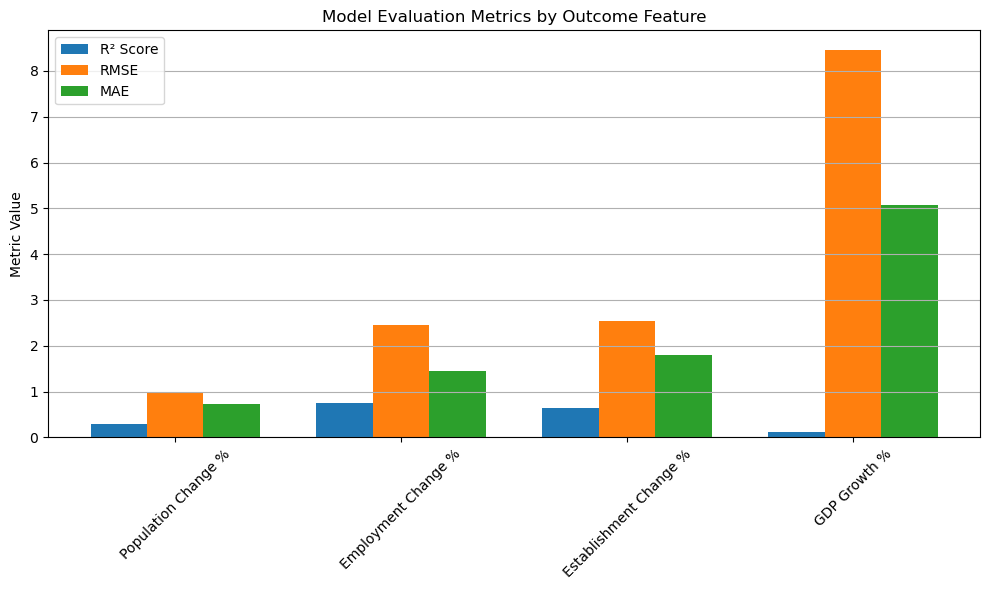

In [14]:
metrics = ['R² Score', 'RMSE', 'MAE']
x = results_ridge_df['Outcome Variable']
bar_width = 0.25
x_indexes = range(len(x))

# Create the plot
plt.figure(figsize=(10, 6))
for i, metric in enumerate(metrics):
    plt.bar(
        [index + i * bar_width for index in x_indexes],
        results_ridge_df[metric],
        width=bar_width,
        label=metric
    )

plt.xticks([index + bar_width for index in x_indexes], x, rotation=45)
plt.ylabel("Metric Value")
plt.title("Model Evaluation Metrics by Outcome Feature")
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [15]:
baseline_results = []

for col in outcome_variables:
    # Step 1: Predict the training mean for this outcome
    baseline_prediction = [y_train[col].mean()] * len(y_test)

    # Step 2: Calculate baseline MAE
    baseline_mae = mean_absolute_error(y_test[col], baseline_prediction)

    # Step 3: Get your model's MAE from results_df
    model_mae = results_ridge_df.loc[results_ridge_df['Outcome Variable'] == col, 'MAE'].values[0]

    # Step 4: Compute improvement
    improvement = (1 - model_mae / baseline_mae) * 100

    baseline_results.append({
        'Outcome Variable': col,
        'Baseline MAE': baseline_mae,
        'Model MAE': model_mae,
        'MAE Improvement (%)': improvement
    })

# Combine into a DataFrame
baseline_comparison_df = pd.DataFrame(baseline_results)
baseline_comparison_df.head()


,Outcome Variable,Baseline MAE,Model MAE,MAE Improvement (%)
0,Population Change %,0.888069,0.721680,18.736122
1,Employment Change %,2.464667,1.439627,41.589372
2,Establishment Change %,3.130143,1.804356,42.355464
3,GDP Growth %,5.478657,5.075577,7.357286


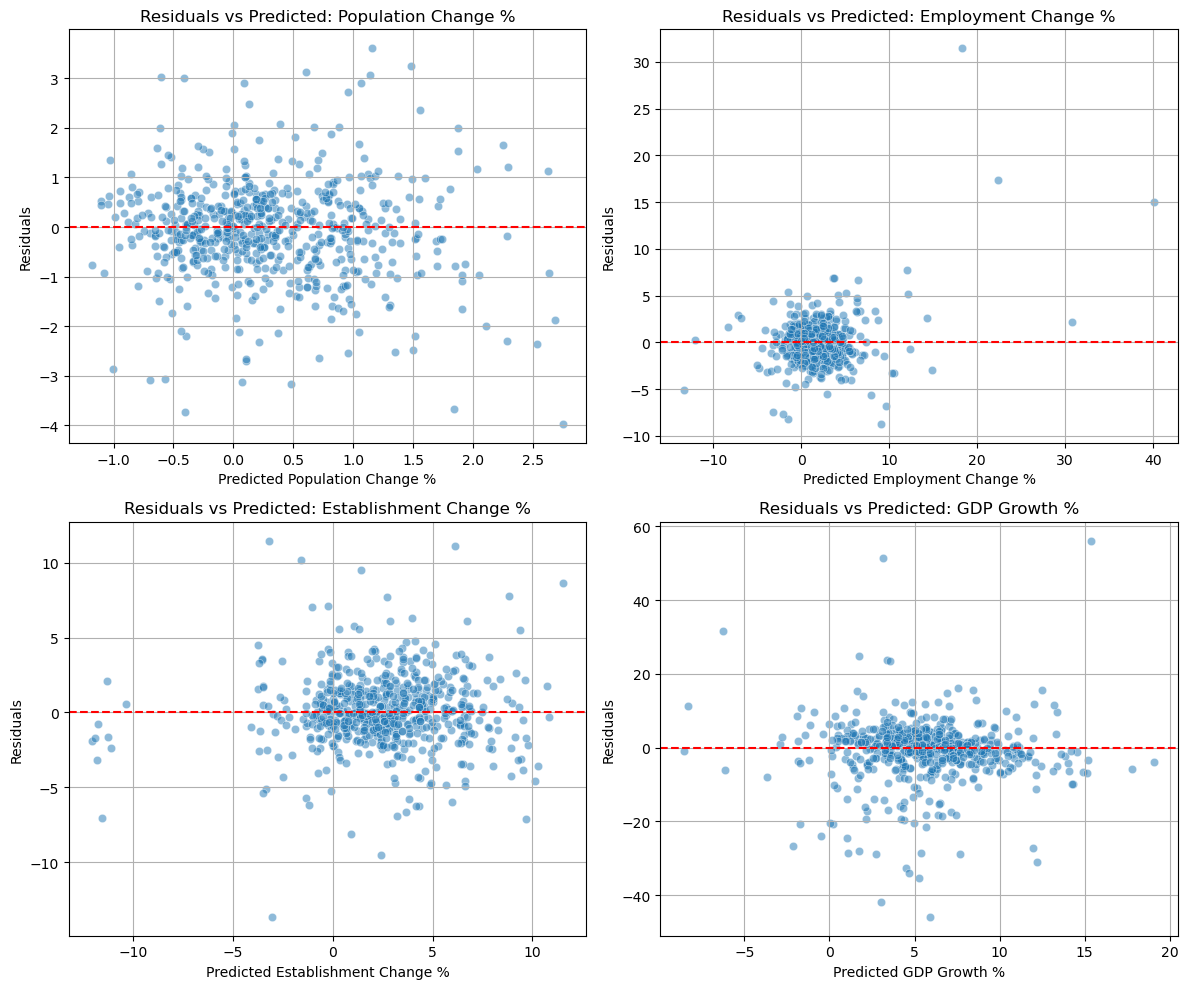

In [16]:
def plot_residuals(y_true, y_pred_ridge_final):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()  # Flatten the 2x2 array of axes for easy indexing

    for i, outcome in enumerate(outcome_variables):
        residuals = y_true.iloc[:, i] - y_pred_ridge_final[:, i]
        ax = axes[i]
        
        sns.scatterplot(x=y_pred_ridge_final[:, i], y=residuals, alpha=0.5, ax=ax)
        ax.axhline(0, color='red', linestyle='--')
        ax.set_title(f'Residuals vs Predicted: {outcome}')
        ax.set_xlabel(f'Predicted {outcome}')
        ax.set_ylabel('Residuals')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_residuals(y_test, y_pred_ridge_final)



In [17]:
top_coefs = {}
top_cont = {}

for i, outcome in enumerate(outcome_variables):
    # Get coefficients
    coefs = pd.Series(
        final_ridge_model.estimators_[i].coef_,
        index=X_train.columns,
        name='Coefficients'
    )

    # Filter to continuous features only
    mask = ~coefs.index.str.startswith('State_') & ~coefs.index.str.startswith('Region_')
    coefs_filtered = coefs[mask]

    # Sort by absolute value to get most impactful features
    top_coefs[outcome] = coefs.sort_values(key=abs, ascending=False)

    top_cont[outcome] = coefs_filtered.sort_values(key=abs, ascending=False)

combined_pop = pd.concat(
        [top_coefs['Population Change %'].head(8).rename("All Features"),
         top_cont['Population Change %'].head(8).rename("Continuous Only")],
        axis=1
    )

display(combined_pop)

# for outcome in outcome_variables:
#     print(f"\nTop 10 Predictors — {outcome}")
#     combined = pd.concat(
#         [top_coefs[outcome].head(10).rename("All Features"),
#          top_cont[outcome].head(10).rename("Continuous Only")],
#         axis=1
#     )

#     display(combined)


,All Features,Continuous Only
State_FL,1.527528,NaN
State_TN,1.040062,NaN
State_ID,0.965809,NaN
State_SC,0.898710,NaN
State_LA,-0.883485,NaN
State_DE,0.814593,NaN
State_NC,0.783381,NaN
State_ME,0.705307,NaN
Median Family Income,NaN,0.521985
Average Temperature,NaN,0.233248


In [18]:
combined_emp = pd.concat(
        [top_coefs['Employment Change %'].head(8).rename("All Features"),
         top_cont['Employment Change %'].head(8).rename("Continuous Only")],
        axis=1
    )

display(combined_emp)

,All Features,Continuous Only
Pct Wage Change,3.280148,3.280148
State_WV,-1.519914,NaN
State_VA*,-1.078964,NaN
State_VA,-1.054394,NaN
State_LA,-1.024573,NaN
State_MI,0.859734,NaN
State_DE,0.855555,NaN
State_MT,-0.808177,NaN
Percent w/ Bachelor's+,NaN,0.295428
Annual Cost,NaN,0.263051


In [19]:
combined_est = pd.concat(
        [top_coefs['Establishment Change %'].head(8).rename("All Features"),
         top_cont['Establishment Change %'].head(8).rename("Continuous Only")],
        axis=1
    )

display(combined_est)

,All Features,Continuous Only
State_WA,-10.187485,NaN
State_VA,-6.565631,NaN
State_WV,6.015774,NaN
State_MT,4.895875,NaN
State_NE,-4.893090,NaN
State_MI,4.877380,NaN
State_VA*,-4.538229,NaN
State_AR,-4.527807,NaN
Average Temperature,NaN,0.573031
Percent w/ Bachelor's+,NaN,0.555906


In [20]:
combined_gdp = pd.concat(
        [top_coefs['GDP Growth %'].head(8).rename("All Features"),
         top_cont['GDP Growth %'].head(8).rename("Continuous Only")],
        axis=1
    )

display(combined_gdp)

,All Features,Continuous Only
State_ND,-7.590855,NaN
State_NE,7.479049,NaN
State_KS,4.799316,NaN
State_IL,-3.466595,NaN
State_FL,3.299121,NaN
State_IA,-3.089591,NaN
State_OK,-2.774399,NaN
State_VT,-2.524144,NaN
Percent w/ Bachelor's+,NaN,1.997415
Average Annual Pay,NaN,-1.317023


In [21]:
rows = []

# Iterate over each outcome and extract top 10 features
for outcome in outcome_variables:
    coefs = top_coefs[outcome]
    for rank, (feature, value) in enumerate(coefs.head(10).items(), start=1):
        rows.append({
            "Outcome Variable": outcome,
            "Rank": rank,
            "Feature": feature,
            "Coefficient": value
        })

# Convert to DataFrame for display/export
top_features_df = pd.DataFrame(rows)

# Optional: Sort by outcome and rank
top_features_df.sort_values(by=["Outcome Variable", "Rank"], inplace=True)
top_features_df.head()

,Outcome Variable,Rank,Feature,Coefficient
10,Employment Change %,1,Pct Wage Change,3.280148
11,Employment Change %,2,State_WV,-1.519914
12,Employment Change %,3,State_VA*,-1.078964
13,Employment Change %,4,State_VA,-1.054394
14,Employment Change %,5,State_LA,-1.024573


In [22]:
X_train_final = X_train_final.astype('float32')
X_test_final = X_test_final.astype('float32')


def build_model(input_dim, output_dim, hidden_units=[64, 32], learning_rate=0.001):
    model = Sequential()
    model.add(Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)))
    model.add(Dense(hidden_units[1], activation='relu'))
    model.add(Dense(output_dim))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mae'
                 )
    return model

model = build_model(input_dim=X_train_final.shape[1], output_dim=y_train_scaled.shape[1])

history = model.fit(
    X_train_final, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
    # callbacks=[early_stop]
)

Epoch 1/100
61/61 [==============================] - 2s 11ms/step - loss: 0.6347 - val_loss: 0.5716
Epoch 2/100
61/61 [==============================] - 0s 4ms/step - loss: 0.5561 - val_loss: 0.5234
Epoch 3/100
61/61 [==============================] - 0s 4ms/step - loss: 0.5172 - val_loss: 0.5030
Epoch 4/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4956 - val_loss: 0.4855
Epoch 5/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4817 - val_loss: 0.4727
Epoch 6/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4711 - val_loss: 0.4698
Epoch 7/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4624 - val_loss: 0.4652
Epoch 8/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4579 - val_loss: 0.4579
Epoch 9/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4523 - val_loss: 0.4564
Epoch 10/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4484 - val_loss: 0.4574
Epoch 11

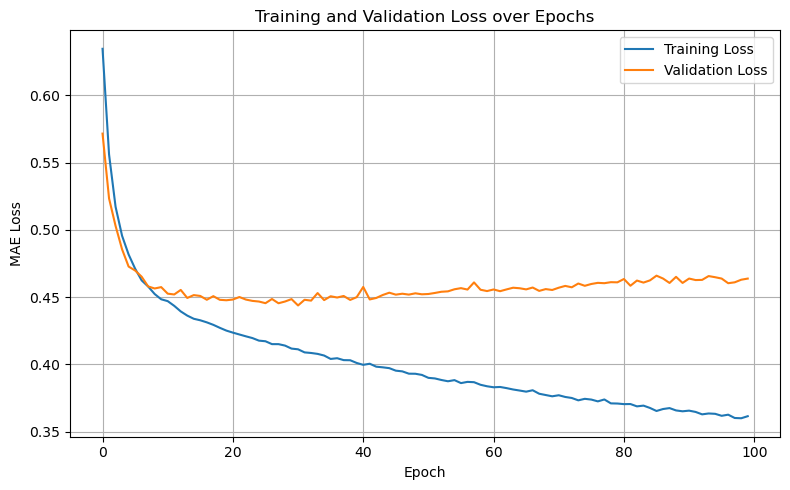

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model = build_model(input_dim=X_train_final.shape[1], output_dim=y_train_scaled.shape[1])

history = model.fit(
    X_train_final, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
61/61 [==============================] - 1s 6ms/step - loss: 0.6309 - val_loss: 0.5711
Epoch 2/100
61/61 [==============================] - 0s 4ms/step - loss: 0.5584 - val_loss: 0.5347
Epoch 3/100
61/61 [==============================] - 0s 4ms/step - loss: 0.5245 - val_loss: 0.5104
Epoch 4/100
61/61 [==============================] - 0s 4ms/step - loss: 0.5051 - val_loss: 0.4930
Epoch 5/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4880 - val_loss: 0.4793
Epoch 6/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4753 - val_loss: 0.4678
Epoch 7/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4674 - val_loss: 0.4627
Epoch 8/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4598 - val_loss: 0.4592
Epoch 9/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4539 - val_loss: 0.4567
Epoch 10/100
61/61 [==============================] - 0s 4ms/step - loss: 0.4485 - val_loss: 0.4556
Epoch 11/

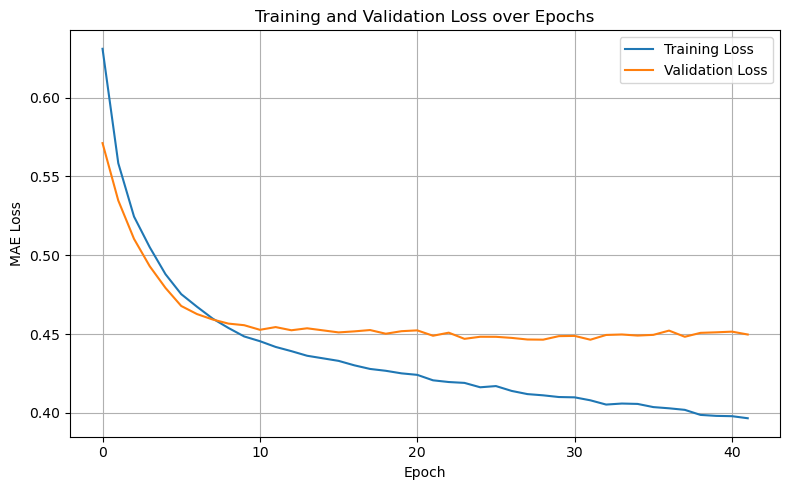

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
y_pred_nn = model.predict(X_test_final)

y_pred_nn_original = y_scaler.inverse_transform(y_pred_nn)
y_test_original = y_scaler.inverse_transform(y_test_scaled)

# Evaluate in original units
results_nn = []
for i, outcome in enumerate(outcome_variables):
    r2 = r2_score(y_test_original[:, i], y_pred_nn_original[:, i])
    rmse = mean_squared_error(y_test_original[:, i], y_pred_nn_original[:, i], squared=False)
    mae = mean_absolute_error(y_test_original[:, i], y_pred_nn_original[:, i])
    results_nn.append({
        'Outcome Variable': outcome,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

# Create and display results DataFrame
results_nn_df = pd.DataFrame(results_nn)
results_nn_df.round(3)

20/20 [==============================] - 0s 2ms/step


,Outcome Variable,R² Score,RMSE,MAE
0,Population Change %,0.336,0.959,0.687
1,Employment Change %,0.735,2.476,1.579
2,Establishment Change %,0.630,2.596,1.860
3,GDP Growth %,0.128,8.433,4.942


In [27]:
def build_model(input_dim, output_dim, hidden_units, learning_rate):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)))
    for units in hidden_units[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(output_dim))  # Output layer

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mae')
    return model

layer_configs = [
    [64, 32],
    [128, 64],
    [32, 16]
]

learning_rates = [0.01, 0.001, 0.0005]

# Track results
tuning_results = []

for config in layer_configs:
    for lr in learning_rates:
        model = build_model(
            input_dim=X_train_final.shape[1],
            output_dim=y_train_scaled.shape[1],
            hidden_units=config,
            learning_rate=lr
        )

        history = model.fit(
            X_train_final, y_train_scaled,
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            verbose=0,
            callbacks=[early_stop]
        )

        final_val_loss = min(history.history['val_loss'])

        tuning_results.append({
            'Hidden Layers': config,
            'Learning Rate': lr,
            'Min Val Loss': final_val_loss
        })

# Convert to DataFrame
tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values(by='Min Val Loss')


,Hidden Layers,Learning Rate,Min Val Loss
5,"[128, 64]",0.0005,0.439193
2,"[64, 32]",0.0005,0.439385
4,"[128, 64]",0.0010,0.442346
1,"[64, 32]",0.0010,0.444068
7,"[32, 16]",0.0010,0.446296
8,"[32, 16]",0.0005,0.449656
6,"[32, 16]",0.0100,0.451669
3,"[128, 64]",0.0100,0.454621
0,"[64, 32]",0.0100,0.457818


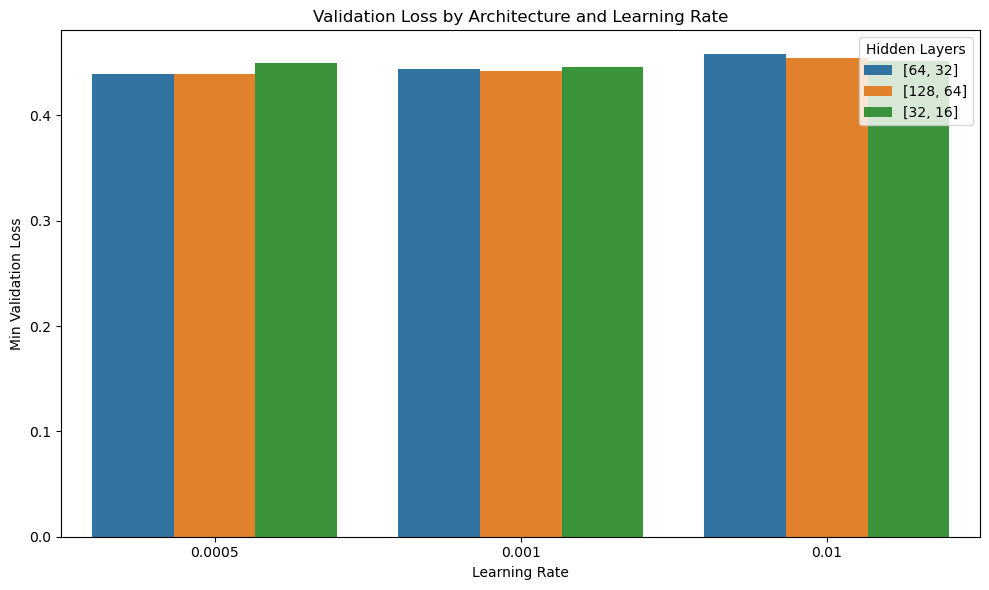

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tuning_df,
    x='Learning Rate',
    y='Min Val Loss',
    hue=tuning_df['Hidden Layers'].astype(str)
)
plt.title('Validation Loss by Architecture and Learning Rate')
plt.ylabel('Min Validation Loss')
plt.tight_layout()
plt.show()


In [38]:
model = build_model(input_dim=X_train_final.shape[1], output_dim=y_train_scaled.shape[1], hidden_units=[128, 64], learning_rate=0.0005)

history = model.fit(
    X_train_final, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/100
61/61 [==============================] - 1s 8ms/step - loss: 0.6222 - val_loss: 0.5632
Epoch 2/100
61/61 [==============================] - 0s 5ms/step - loss: 0.5569 - val_loss: 0.5379
Epoch 3/100
61/61 [==============================] - 0s 5ms/step - loss: 0.5302 - val_loss: 0.5191
Epoch 4/100
61/61 [==============================] - 0s 4ms/step - loss: 0.5113 - val_loss: 0.5059
Epoch 5/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4969 - val_loss: 0.4902
Epoch 6/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4838 - val_loss: 0.4810
Epoch 7/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4733 - val_loss: 0.4715
Epoch 8/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4646 - val_loss: 0.4616
Epoch 9/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4578 - val_loss: 0.4614
Epoch 10/100
61/61 [==============================] - 0s 5ms/step - loss: 0.4520 - val_loss: 0.4555
Epoch 11/

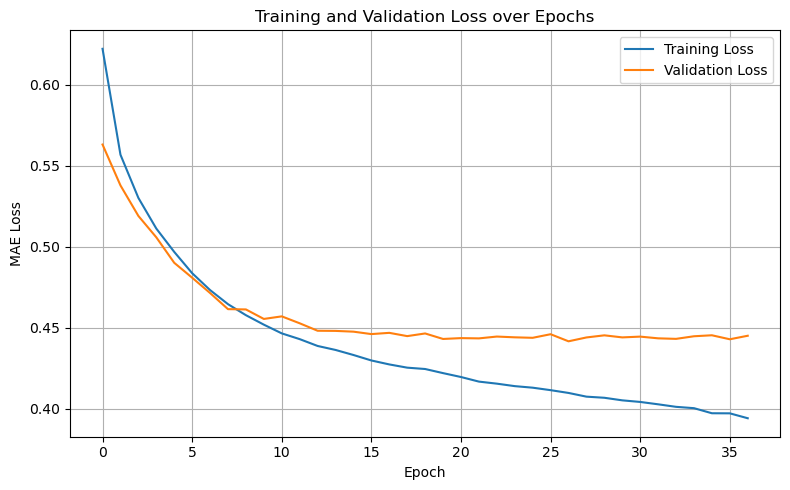

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
y_pred_nn = model.predict(X_test_final)
y_pred_nn_original = y_scaler.inverse_transform(y_pred_nn)
y_test_original = y_scaler.inverse_transform(y_test_scaled)

# Evaluate in original units
results_nn = []
for i, outcome in enumerate(outcome_variables):
    r2 = r2_score(y_test_original[:, i], y_pred_nn_original[:, i])
    rmse = mean_squared_error(y_test_original[:, i], y_pred_nn_original[:, i], squared=False)
    mae = mean_absolute_error(y_test_original[:, i], y_pred_nn_original[:, i])
    results_nn.append({
        'Outcome Variable': outcome,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

# Create and display results DataFrame
results_nn_df = pd.DataFrame(results_nn)
results_nn_df.round(3)

20/20 [==============================] - 0s 2ms/step


,Outcome Variable,R² Score,RMSE,MAE
0,Population Change %,0.362,0.940,0.672
1,Employment Change %,0.728,2.507,1.587
2,Establishment Change %,0.644,2.546,1.807
3,GDP Growth %,0.142,8.367,4.853


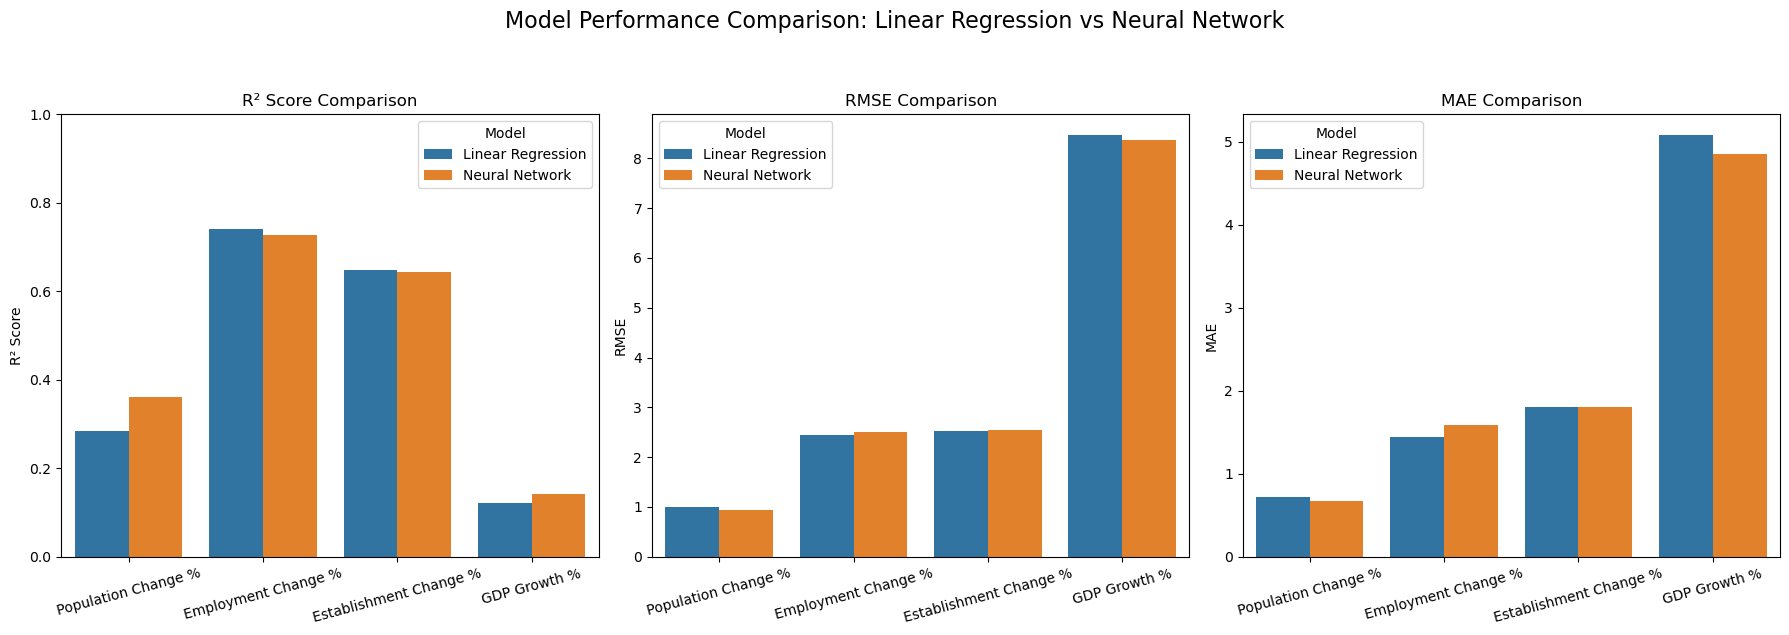

In [47]:
results_linear = results_ridge_df.copy()
results_linear['Model'] = 'Linear Regression'

results_nn_df['Model'] = 'Neural Network'

comparison_df = pd.concat([results_linear, results_nn_df])
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Metric and title info
metrics = ['R² Score', 'RMSE', 'MAE']
titles = ['R² Score Comparison', 'RMSE Comparison', 'MAE Comparison']
y_labels = ['R² Score', 'RMSE', 'MAE']

# Plot each metric
for i, metric in enumerate(metrics):
    sns.barplot(
        data=comparison_df,
        x='Outcome Variable',
        y=metric,
        hue='Model',
        ax=axes[i]
    )
    axes[i].set_title(titles[i])
    axes[i].set_ylabel(y_labels[i])
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    if metric == 'R² Score':
        axes[i].set_ylim(0, 1)

# Overall title and layout
fig.suptitle('Model Performance Comparison: Linear Regression vs Neural Network', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# # R² Comparison
# plt.figure(figsize=(10, 5))
# sns.barplot(data=comparison_df, x='Outcome Variable', y='R² Score', hue='Model')
# plt.title('R² Score Comparison: Linear Regression vs Neural Network')
# plt.ylabel('R² Score')
# plt.xticks(rotation=15)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()

# # RMSE Comparison
# plt.figure(figsize=(10, 5))
# sns.barplot(data=comparison_df, x='Outcome Variable', y='RMSE', hue='Model')
# plt.title('RMSE Comparison: Linear Regression vs Neural Network')
# plt.ylabel('RMSE')
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(10, 5))
# sns.barplot(data=comparison_df, x='Outcome Variable', y='MAE', hue='Model')
# plt.title('MAE Comparison: Linear Regression vs Neural Network')
# plt.ylabel('MAE')
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

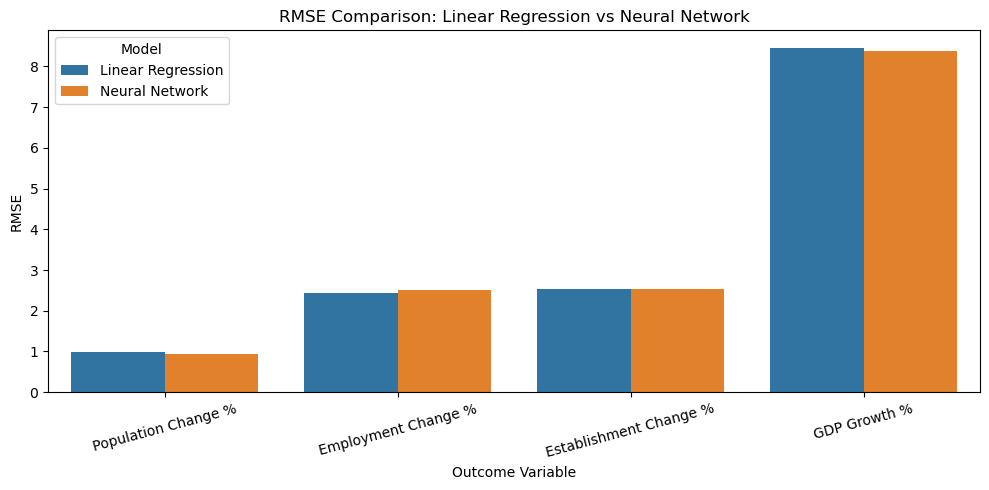

In [45]:
# RMSE Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Outcome Variable', y='RMSE', hue='Model')
plt.title('RMSE Comparison: Linear Regression vs Neural Network')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

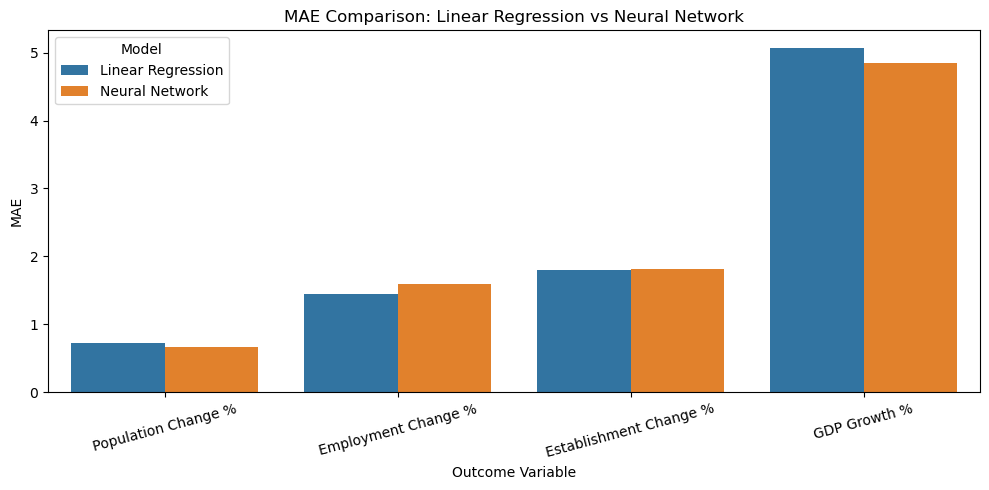

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Outcome Variable', y='MAE', hue='Model')
plt.title('MAE Comparison: Linear Regression vs Neural Network')
plt.ylabel('MAE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The figure layout has changed to tight


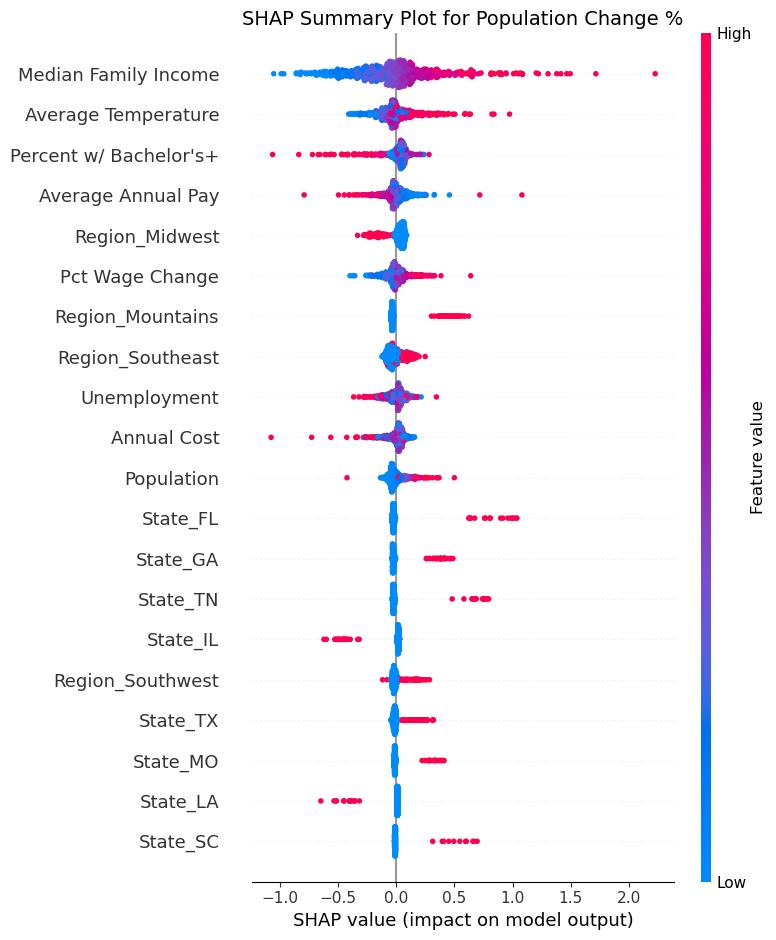

In [56]:


# Create the explainer using a subset of your training data
explainer = shap.DeepExplainer(model, X_test_final.to_numpy())  # use a sample if the full set is large

# Get SHAP values
shap_values = explainer.shap_values(X_test_final.to_numpy())

# For multi-output, shap_values is a list — one array per output
# You can visualize SHAP for a specific output variable like this:
for i, outcome in enumerate(outcome_variables):
    shap.summary_plot(shap_values[i], X_test_final.to_numpy(), feature_names=X.columns, show=False)
    plt.title(f'SHAP Summary Plot for {outcome}', fontsize=14)
    plt.tight_layout()
    plt.show()
    break



In [34]:
for i, outcome in enumerate(outcome_variables):
    # Get SHAP values for this output variable
    shap_vals = shap_values[i]  # shape: (n_samples, n_features)

    # Compute mean absolute SHAP value per feature
    mean_contrib = np.abs(shap_vals).mean(axis=0)

    # Create a DataFrame for this output
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Mean |SHAP Value|': mean_contrib
    }).sort_values(by='Mean |SHAP Value|', ascending=False)

    # Print nicely
    print(f"\nTop Features Contributing to Predictions of {outcome}")
    print(feature_importance_df.head(10).to_string(index=False))  # top 10 features


Top Features Contributing to Predictions of Population Change %
               Feature  Mean |SHAP Value|
  Median Family Income           0.247880
   Average Temperature           0.118164
Percent w/ Bachelor's+           0.097766
        Region_Midwest           0.073659
       Pct Wage Change           0.070385
          Unemployment           0.065017
      Region_Southeast           0.063674
            Population           0.063518
    Average Annual Pay           0.063207
           Annual Cost           0.054838

Top Features Contributing to Predictions of Employment Change %
               Feature  Mean |SHAP Value|
       Pct Wage Change           0.503731
           Annual Cost           0.043236
   Average Temperature           0.041178
    Average Annual Pay           0.039327
  Median Family Income           0.037529
Percent w/ Bachelor's+           0.037273
            Population           0.035483
      Region_Southeast           0.030612
          Unemployment        

In [35]:
for i, outcome in enumerate(outcome_variables):
    # Get SHAP values for this output variable
    shap_vals = shap_values[i]  # shape: (n_samples, n_features)

    # Compute signed mean SHAP value per feature
    mean_signed_contrib = shap_vals.mean(axis=0)

    # Create a DataFrame for this output
    signed_feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Mean SHAP Value': mean_signed_contrib
    }).sort_values(by='Mean SHAP Value', ascending=False)

    # Print nicely
    print(f"\nTop 10 Features (Signed) Contributing to Predictions of {outcome}")
    print(signed_feature_importance_df.head(10).to_string(index=False))  # Top 10 increasing

    print(f"\nTop 10 Features (Negative) Contributing to Predictions of {outcome}")
    print(signed_feature_importance_df.tail(10).sort_values(by='Mean SHAP Value').to_string(index=False))  # Top 10 decreasing



Top 10 Features (Signed) Contributing to Predictions of Population Change %
           Feature  Mean SHAP Value
      Unemployment         0.008566
  Region_Southeast         0.005888
          State_FL         0.005553
          State_GA         0.004286
          State_PA         0.004189
          State_MI         0.002358
    Region_Midwest         0.002241
          State_NM         0.002193
Average Annual Pay         0.001776
          State_MD         0.001748

Top 10 Features (Negative) Contributing to Predictions of Population Change %
             Feature  Mean SHAP Value
Median Family Income        -0.014433
         Annual Cost        -0.008809
            State_NC        -0.007102
          Population        -0.006581
            State_CA        -0.004097
            State_WV        -0.002867
            State_KY        -0.002583
            State_IL        -0.002329
            State_LA        -0.001793
            State_VA        -0.001680

Top 10 Features (Signed) Cont

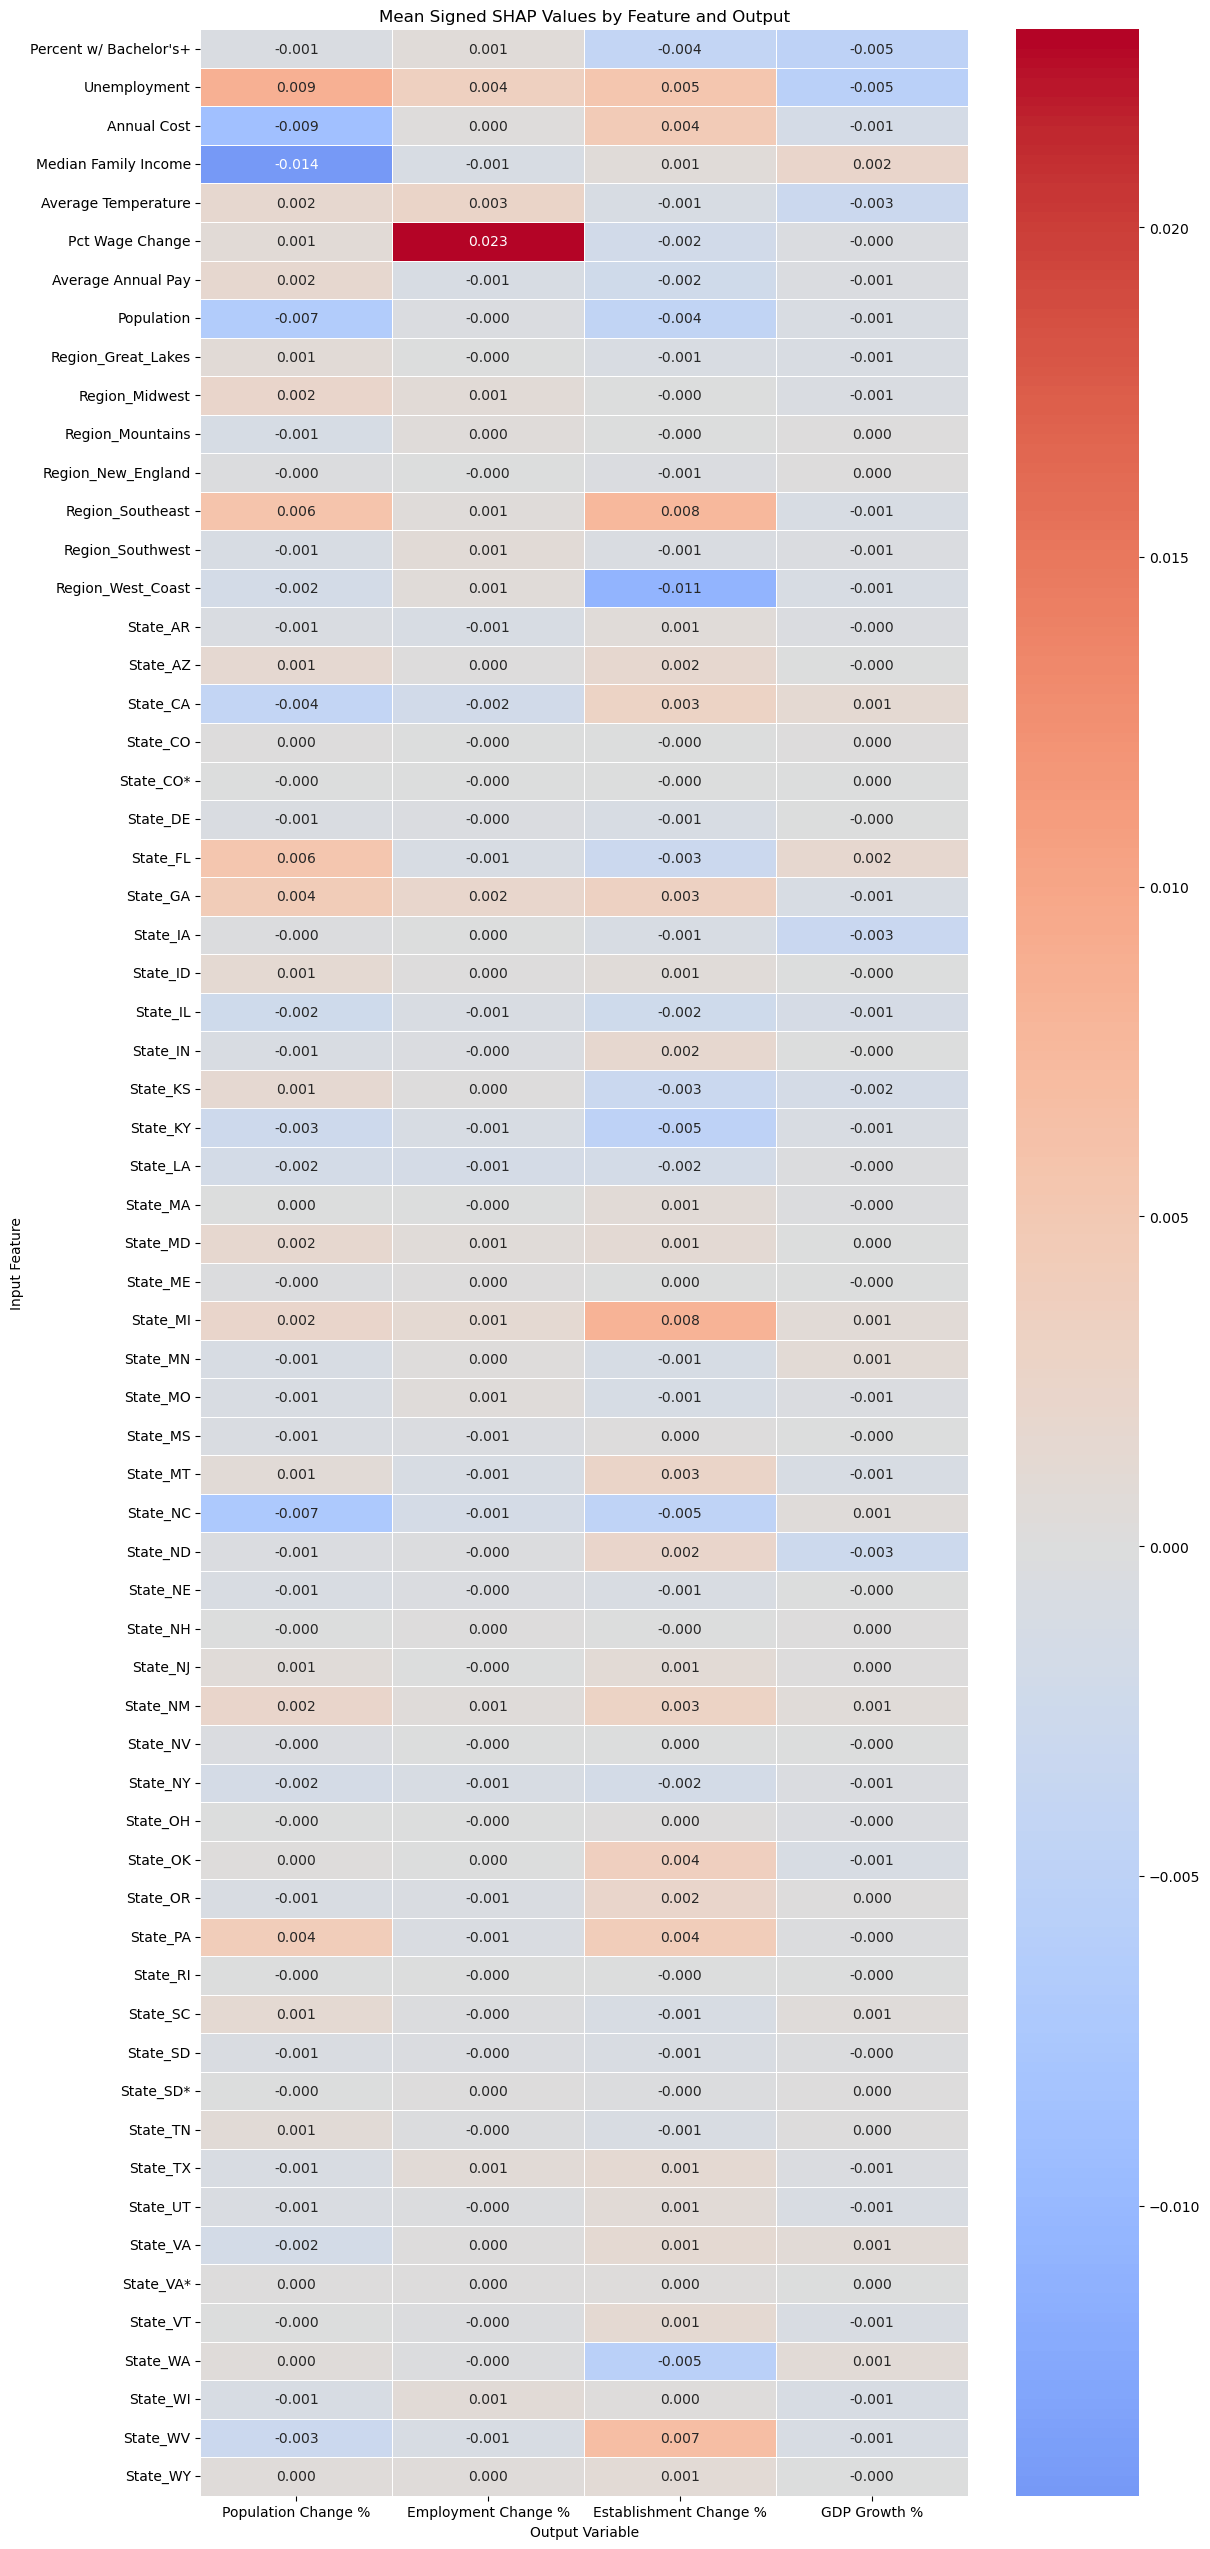

In [36]:
signed_means_df = pd.DataFrame(index=X.columns)

# Loop over each output variable and compute signed mean SHAP values
for i, outcome in enumerate(outcome_variables):
    shap_vals = shap_values[i]
    mean_signed = shap_vals.mean(axis=0)  # mean across rows (samples)
    signed_means_df[outcome] = mean_signed

# Optional: round for clarity
signed_means_df = signed_means_df.round(4)

# Plot heatmap
plt.figure(figsize=(12, len(X.columns) * 0.4))  # Adjust height to # of features
sns.heatmap(signed_means_df, cmap='coolwarm', center=0, annot=True, fmt=".3f", linewidths=0.5)

plt.title("Mean Signed SHAP Values by Feature and Output")
plt.xlabel("Output Variable")
plt.ylabel("Input Feature")
plt.tight_layout()
plt.show()